Dataset & Problem Statement

Scenario: You are a data analyst at a retail company. The sales team needs a monthly performance dashboard that shows trends, category comparisons, and revenue contribution breakdowns. You have been given raw monthly data.



In [45]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import pandas as pd

In [46]:
data = {
    'Month' : ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],

    'Sales' : [200, 300, 250, 400, 380, 450, 420, 500, 470, 520, 600, 750],

    'Target': [220, 280, 300, 380, 400, 430, 450, 480, 490, 510, 580, 700],

    'Returns': [10, 15, 12, 20, 18, 22, 21, 25, 23, 26, 30, 38],

    'Category' : ['Electronics', 'Electronics', 'Apparel', 'Apparel', 'Electronics', 'FMCG', 'FMCG', 'Electronics', 'Apparel','FMCG','Electronics','Apparel']
}

In [47]:
df = pd.DataFrame(data)
df['Net_Sales'] = df['Sales'] - df['Returns']
df['vs_Target'] = df['Sales'] - df['Target']

Building the Dashboard

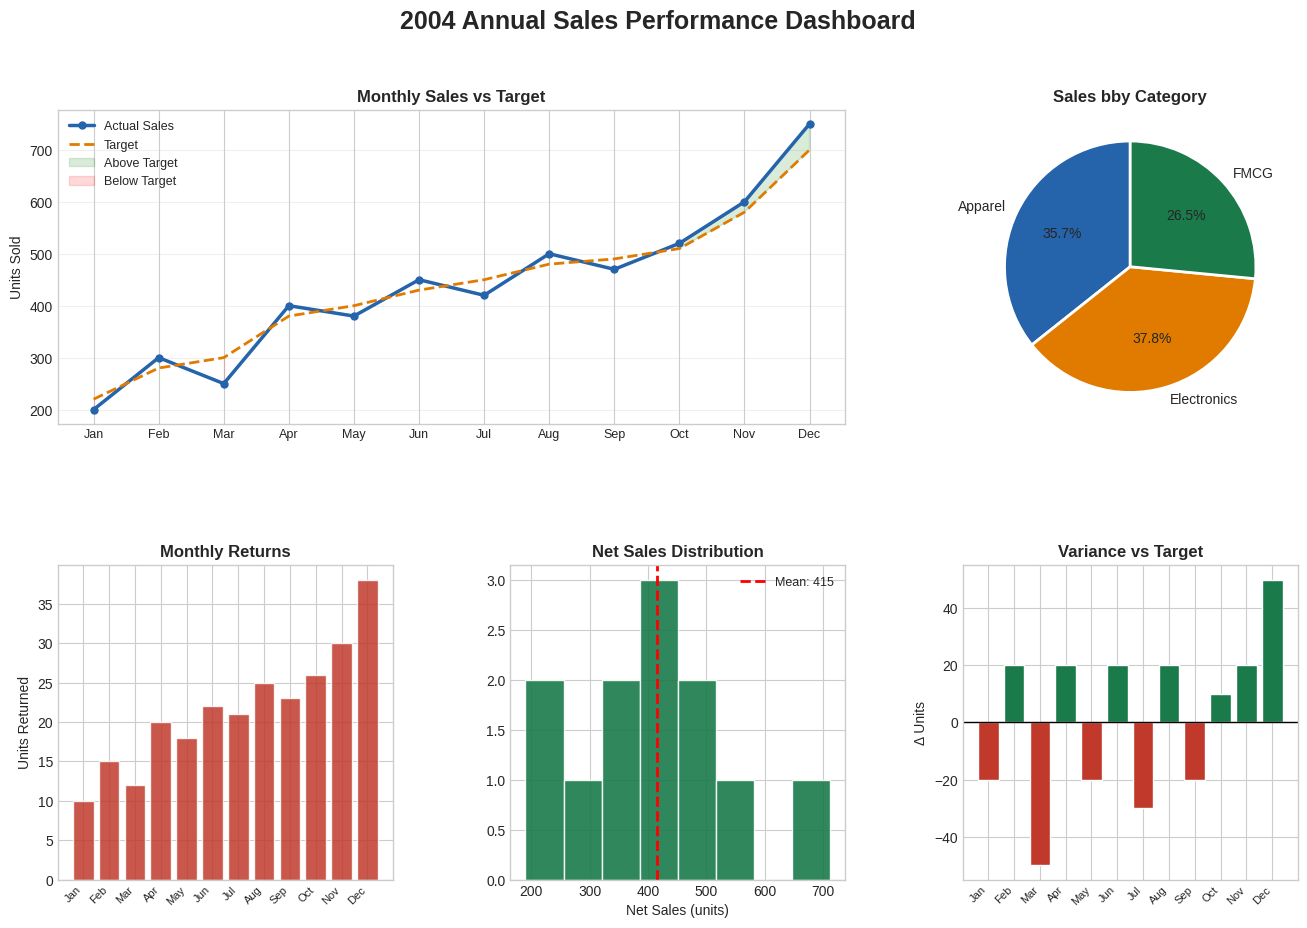

Dashboard saved as sales_dashboard.png


In [62]:
plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 10))

fig.suptitle('2004 Annual Sales Performance Dashboard', fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

months = df['Month']
x = range(len(months))

ax1.plot(x, df['Sales'], label = 'Actual Sales', color="#2563AB", linewidth=2.5, marker='o', markersize=5)

ax1.plot(x, df['Target'], label='Target', color = '#E07B00', linewidth=2, linestyle='--')

ax1.fill_between(x, df['Target'], df['Sales'], where=df['Sales'] >= df['Target'], alpha=0.15, color='green', label='Above Target')

ax1.fill_between(x, df['Target'], df['Sales'], where=df['Sales'] < df['Target'], alpha=0.15, color='red', label='Below Target')

ax1.set_xticks(x)
ax1.set_xticklabels(months, fontsize=9)
ax1.set_title('Monthly Sales vs Target', fontweight='bold')
ax1.set_ylabel('Units Sold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

cat_sales = df.groupby('Category')['Sales'].sum()
colors2 = ['#2563AB', '#E07B00', '#1A7A4A']
ax2.pie(cat_sales, labels=cat_sales.index, autopct='%1.1f%%', colors=colors2, startangle = 90, wedgeprops={'edgecolor':'white', 'linewidth':2})
ax2.set_title('Sales bby Category', fontweight='bold')

ax3.bar(x, df['Returns'], color='#C0392B', edgecolor='white', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(months, rotation=45, fontsize = 8, ha='right')
ax3.set_title('Monthly Returns', fontweight='bold')
ax3.set_ylabel('Units Returned')

ax4.hist(df['Net_Sales'], bins=8, color='#1A7A4A',
         edgecolor='white', alpha=0.9)
ax4.axvline(df['Net_Sales'].mean(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mean: {df["Net_Sales"].mean():.0f}')
ax4.set_title('Net Sales Distribution', fontweight='bold')
ax4.set_xlabel('Net Sales (units)')
ax4.legend(fontsize=9)

bar_colours = ['#1A7A4A' if v >= 0 else '#C0392B'
               for v in df['vs_Target']]
ax5.bar(x, df['vs_Target'], color=bar_colours, edgecolor='white')
ax5.axhline(0, color='black', linewidth=1)
ax5.set_xticks(x)
ax5.set_xticklabels(months, rotation=45, fontsize=8, ha='right')
ax5.set_title('Variance vs Target', fontweight='bold')
ax5.set_ylabel('Δ Units')

plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')

plt.show()

print('Dashboard saved as sales_dashboard.png')